# GARCH(1,1) Maximum-Likelihood Optimization

**Academic numerical-optimization case study — self-contained notebook**

This notebook develops the mathematics before the implementation. It contains everything needed to run the study: the constrained statistical model, analytic derivatives, a custom inverse-BFGS optimizer with Armijo backtracking, convergence qualifications, numerical derivative checks, a synthetic recovery experiment, a real OTE equity-return application, inference, diagnostics, plots, and comparison with SciPy's reference BFGS solver.

**Learning goals**

1. Express Gaussian GARCH estimation as a constrained nonlinear minimization problem.
2. Differentiate a recursive state equation analytically.
3. enforce $\omega>0$, $\alpha,\beta\ge 0$, and $\alpha+\beta<1$ through a smooth reparameterization.
4. Implement and audit BFGS rather than treating optimization as a black box.
5. distinguish optimizer convergence, statistical inference, and model diagnostics.

## 1. Model, assumptions, and admissible parameter set

For returns $r_1,\ldots,r_T$,

$$
r_t=\mu+\varepsilon_t,\qquad
\varepsilon_t=\sqrt{h_t}z_t,\qquad z_t\overset{iid}{\sim}N(0,1),
$$

with conditional-variance recursion

$$
h_t=\omega+\alpha\varepsilon_{t-1}^2+\beta h_{t-1},
\qquad \theta=(\mu,\omega,\alpha,\beta)^\top.
$$

We optimize over

$$
\Theta=\{\theta:\omega>0,\;\alpha\ge0,\;\beta\ge0,\;\alpha+\beta<1\}.
$$

Non-negativity ensures $h_t>0$. The last inequality is the finite-second-moment (weak covariance-stationarity) condition and gives

$$
\bar h=\operatorname{Var}(\varepsilon_t)=\frac{\omega}{1-\alpha-\beta}.
$$

It should not be confused with strict stationarity, associated with
$E[\log(\alpha z_t^2+\beta)]<0$, or the Gaussian finite-fourth-moment condition
$3\alpha^2+2\alpha\beta+\beta^2<1$. The estimator below imposes only the finite-second-moment condition. For non-Gaussian financial returns the Gaussian criterion may be interpreted as a **quasi-likelihood**; model-based standard errors are then illustrative and robust sandwich inference would be preferable.

## 2. Conditional likelihood and optimization problem

We initialize the filter at the parameter-dependent unconditional variance,

$$h_1=\frac{\omega}{1-\alpha-\beta}.$$

Conditional Gaussian log-likelihood contribution:

$$
\ell_t(\theta)=-\frac12\left[\log(2\pi)+\log h_t+
\frac{\varepsilon_t^2}{h_t}\right].
$$

Therefore the maximum-likelihood estimator solves

$$
\widehat\theta=\arg\min_{\theta\in\Theta} f(\theta),\qquad
f(\theta)=-\sum_{t=1}^T\ell_t(\theta).
$$

We sum log-densities rather than multiply densities, avoiding numerical underflow. The GARCH likelihood is generally **non-convex**. A small gradient and a successful local solver do not prove global optimality; dispersed starts and an independent solver are therefore part of the experiment.

## 3. Analytic score recursion

Let

$$q=\nabla_\theta\varepsilon_t=(-1,0,0,0)^\top,
\qquad d_t=\nabla_\theta h_t.$$

Since $h_1$ depends on $(\omega,\alpha,\beta)$,

$$
d_1=\left(0,\frac{1}{1-\alpha-\beta},
\frac{\omega}{(1-\alpha-\beta)^2},
\frac{\omega}{(1-\alpha-\beta)^2}\right)^\top.
$$

For $t\ge2$, differentiation of the filter gives

$$
d_t=
\begin{pmatrix}0\\1\\\varepsilon_{t-1}^2\\h_{t-1}\end{pmatrix}
+2\alpha\varepsilon_{t-1}q+\beta d_{t-1}.
$$

Thus the negative-log-likelihood gradient contribution is

$$
\nabla_\theta f_t=\frac12\left[
\left(\frac1{h_t}-\frac{\varepsilon_t^2}{h_t^2}\right)d_t
\frac{2\varepsilon_t}{h_t}q\right].
$$

The variance and derivative recursions are evaluated together in $O(T)$ time and $O(T)$ storage here (storage can be reduced to $O(1)$ if only the objective and score are required). A central finite-difference check will independently test this analytic score.

## 4. Smooth constraint transform

Direct constrained optimization near $\alpha+\beta=1$ is awkward. Instead optimize over $u\in\mathbb R^4$. With $c=1-10^{-8}$ and
$D=1+e^{u_\alpha}+e^{u_\beta}$, define

$$
\mu=u_\mu,\qquad \omega=e^{u_\omega},\qquad
\alpha=c\frac{e^{u_\alpha}}{D},\qquad
\beta=c\frac{e^{u_\beta}}{D}.
$$

This map automatically gives $\omega>0$, $\alpha>0$, $\beta>0$ and $\alpha+\beta<c<1$. By the chain rule,

$$\nabla_u f=J_{\theta\leftarrow u}^{\top}\nabla_\theta f.$$

Interior parameter values can be mapped back to $u$ using log-ratios relative to the stationarity slack $c-\alpha-\beta$.

In [7]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import chi2, norm

np.set_printoptions(precision=6, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")

STATIONARITY_MARGIN = 1e-8

@dataclass(frozen=True)
class GARCHParameters:
    mu: float
    omega: float
    alpha: float
    beta: float

    @property
    def persistence(self):
        return self.alpha + self.beta

    @property
    def unconditional_variance(self):
        return self.omega / (1.0 - self.persistence)

    def as_array(self):
        return np.array([self.mu, self.omega, self.alpha, self.beta], dtype=float)

    def validate(self):
        x = self.as_array()
        if not np.all(np.isfinite(x)):
            raise ValueError("Parameters must be finite.")
        if self.omega <= 0 or self.alpha < 0 or self.beta < 0 or self.persistence >= 1:
            raise ValueError("Need omega>0, alpha>=0, beta>=0, alpha+beta<1.")


def unconstrained_to_natural(u, margin=STATIONARITY_MARGIN):
    u = np.asarray(u, dtype=float)
    scale = 1.0 - margin
    logits = np.array([u[2], u[3], 0.0])
    logits -= logits.max()
    weights = np.exp(logits)
    weights /= weights.sum()
    result = GARCHParameters(
        float(u[0]), float(np.exp(np.clip(u[1], -700, 700))),
        float(scale * weights[0]), float(scale * weights[1])
    )
    result.validate()
    return result


def natural_to_unconstrained(theta, margin=STATIONARITY_MARGIN):
    theta.validate()
    slack = 1.0 - margin - theta.alpha - theta.beta
    if min(theta.alpha, theta.beta, slack) <= 0:
        raise ValueError("Inverse transform requires an interior point.")
    return np.array([
        theta.mu, np.log(theta.omega),
        np.log(theta.alpha / slack), np.log(theta.beta / slack)
    ])


def transform_jacobian(u, margin=STATIONARITY_MARGIN):
    theta = unconstrained_to_natural(u, margin)
    scale = 1.0 - margin
    J = np.zeros((4, 4))
    J[0, 0] = 1.0
    J[1, 1] = theta.omega
    J[2, 2] = theta.alpha * (1.0 - theta.alpha / scale)
    J[2, 3] = -theta.alpha * theta.beta / scale
    J[3, 2] = -theta.alpha * theta.beta / scale
    J[3, 3] = theta.beta * (1.0 - theta.beta / scale)
    return J


def simulate_garch11(n, theta, burn=500, seed=0):
    theta.validate()
    rng = np.random.default_rng(seed)
    total = n + burn
    z = rng.standard_normal(total)
    r, eps, h = np.empty(total), np.empty(total), np.empty(total)
    h[0] = theta.unconditional_variance
    eps[0] = np.sqrt(h[0]) * z[0]
    r[0] = theta.mu + eps[0]
    for t in range(1, total):
        h[t] = theta.omega + theta.alpha * eps[t-1]**2 + theta.beta * h[t-1]
        eps[t] = np.sqrt(h[t]) * z[t]
        r[t] = theta.mu + eps[t]
    return r[burn:], h[burn:]


def filter_variance(returns, theta):
    x = np.asarray(returns, dtype=float)
    eps = x - theta.mu
    h = np.empty_like(x)
    h[0] = theta.unconditional_variance
    for t in range(1, len(x)):
        h[t] = theta.omega + theta.alpha * eps[t-1]**2 + theta.beta * h[t-1]
    return h


def gaussian_nll_and_gradient(u, returns):
    x = np.asarray(returns, dtype=float)
    theta = unconstrained_to_natural(u)
    eps = x - theta.mu
    omega, alpha, beta = theta.omega, theta.alpha, theta.beta
    h = np.empty_like(x)
    d = np.empty((len(x), 4))
    h[0] = omega / (1.0 - alpha - beta)
    d[0] = [0.0, 1.0/(1-alpha-beta),
            omega/(1-alpha-beta)**2, omega/(1-alpha-beta)**2]
    for t in range(1, len(x)):
        h[t] = omega + alpha * eps[t-1]**2 + beta * h[t-1]
        d[t, 0] = -2.0 * alpha * eps[t-1] + beta * d[t-1, 0]
        d[t, 1] = 1.0 + beta * d[t-1, 1]
        d[t, 2] = eps[t-1]**2 + beta * d[t-1, 2]
        d[t, 3] = h[t-1] + beta * d[t-1, 3]
    if np.any(h <= 0) or not np.all(np.isfinite(h)):
        return np.inf, np.full(4, np.nan)
    nll = 0.5 * np.sum(np.log(2*np.pi) + np.log(h) + eps**2/h)
    coefficient = 1.0/h - eps**2/h**2
    gradient_theta = 0.5 * np.sum(coefficient[:, None] * d, axis=0)
    gradient_theta[0] -= np.sum(eps/h)
    gradient_u = transform_jacobian(u).T @ gradient_theta
    return float(nll), gradient_u

## 5. Custom inverse-BFGS with Armijo backtracking

At iteration $k$, with inverse-Hessian approximation $H_k$,

$$p_k=-H_k\nabla f(u_k),\qquad u_{k+1}=u_k+a_kp_k.$$

Armijo backtracking selects the first $a_k\in\{1,\tau,\tau^2,\ldots\}$ satisfying

$$f(u_k+a_kp_k)\le f(u_k)+c_1a_k\nabla f(u_k)^\top p_k.$$

With $s_k=u_{k+1}-u_k$, $y_k=\nabla f(u_{k+1})-\nabla f(u_k)$ and
$\rho_k=(y_k^\top s_k)^{-1}$, inverse-BFGS uses

$$
H_{k+1}=(I-\rho_ks_ky_k^\top)H_k(I-\rho_ky_ks_k^\top)
+\rho_ks_ks_k^\top.
$$

Safeguards: reset to steepest descent if the proposed direction is not descent; skip the update when $y_k^\top s_k$ is too small; stop on gradient tolerance, simultaneous step/objective stagnation, failed line search, or the iteration limit.

Armijo ensures sufficient decrease, but classical superlinear BFGS results generally assume stronger smoothness/curvature conditions and Wolfe-type searches. Because the GARCH likelihood is non-convex, our evidence is numerical rather than a global-convergence proof.

In [8]:
def bfgs_minimize(objective, x0, gtol=1e-6, xtol=1e-10, ftol=1e-12,
                  max_iter=500, armijo=1e-4, contraction=0.5):
    x = np.asarray(x0, dtype=float).copy()
    f, g = objective(x)
    H = np.eye(len(x))
    nfev = 1
    history = [{"iteration": 0, "objective": f,
                "gradient_inf_norm": np.linalg.norm(g, np.inf), "step_size": 0.0}]
    for iteration in range(1, max_iter + 1):
        if np.linalg.norm(g, np.inf) <= gtol:
            return {"x": x, "fun": f, "jac": g, "success": True,
                    "message": "gradient tolerance", "nit": iteration-1,
                    "nfev": nfev, "history": pd.DataFrame(history)}
        p = -H @ g
        directional = float(g @ p)
        if directional >= -1e-14 * max(1.0, np.linalg.norm(g)):
            p, H = -g, np.eye(len(x))
            directional = -float(g @ g)
        a = 1.0
        accepted = False
        while a >= 1e-12:
            candidate = x + a*p
            f_new, g_new = objective(candidate)
            nfev += 1
            if np.isfinite(f_new) and np.all(np.isfinite(g_new)) and \
               f_new <= f + armijo*a*directional:
                accepted = True
                break
            a *= contraction
        if not accepted:
            return {"x": x, "fun": f, "jac": g, "success": False,
                    "message": "Armijo line search failed", "nit": iteration-1,
                    "nfev": nfev, "history": pd.DataFrame(history)}
        s, y = candidate-x, g_new-g
        curvature = float(y @ s)
        if curvature > 1e-12 * max(1.0, np.linalg.norm(s)*np.linalg.norm(y)):
            rho = 1.0/curvature
            V = np.eye(len(x)) - rho*np.outer(s, y)
            H = V @ H @ V.T + rho*np.outer(s, s)
        previous_f = f
        x, f, g = candidate, float(f_new), g_new
        history.append({"iteration": iteration, "objective": f,
                        "gradient_inf_norm": np.linalg.norm(g, np.inf), "step_size": a})
        small_step = np.linalg.norm(s) <= xtol*(1 + np.linalg.norm(x))
        small_change = abs(previous_f-f) <= ftol*(1 + abs(previous_f))
        if small_step and small_change:
            return {"x": x, "fun": f, "jac": g, "success": True,
                    "message": "step and objective tolerances", "nit": iteration,
                    "nfev": nfev, "history": pd.DataFrame(history)}
    return {"x": x, "fun": f, "jac": g, "success": False,
            "message": "maximum iterations", "nit": max_iter,
            "nfev": nfev, "history": pd.DataFrame(history)}


def default_start(returns):
    variance = max(float(np.var(returns)), 1e-6)
    return natural_to_unconstrained(
        GARCHParameters(float(np.mean(returns)), 0.05*variance, 0.10, 0.85)
    )


def fit_custom(returns, start=None):
    x = np.asarray(returns, dtype=float)
    x0 = default_start(x) if start is None else np.asarray(start, dtype=float)
    result = bfgs_minimize(lambda u: gaussian_nll_and_gradient(u, x), x0)
    result["theta"] = unconstrained_to_natural(result["x"])
    result["method"] = "Custom BFGS + Armijo"
    return result


def fit_reference(returns, start=None):
    x = np.asarray(returns, dtype=float)
    x0 = default_start(x) if start is None else np.asarray(start, dtype=float)
    result = minimize(
        lambda u: gaussian_nll_and_gradient(u, x)[0], x0,
        jac=lambda u: gaussian_nll_and_gradient(u, x)[1], method="BFGS",
        options={"gtol": 1e-6, "maxiter": 1000}
    )
    return {"x": result.x, "fun": float(result.fun), "jac": result.jac,
            "success": bool(result.success), "message": str(result.message),
            "nit": int(result.nit), "nfev": int(result.nfev),
            "theta": unconstrained_to_natural(result.x),
            "method": "SciPy BFGS reference"}

## 6. Controlled synthetic experiment and derivative audit

We simulate from the known target

$$
(\mu,\omega,\alpha,\beta)=(0.02,0.05,0.08,0.88),
\qquad \alpha+\beta=0.96,
$$

retaining $T=4000$ observations after a burn-in of 1000 with seed 2026. Before fitting, the analytic gradient is compared with a central finite-difference approximation at an interior point. The relative discrepancy should be near numerical precision.

In [9]:
TRUE_THETA = GARCHParameters(0.02, 0.05, 0.08, 0.88)
SYNTHETIC_RETURNS, TRUE_VARIANCE = simulate_garch11(
    4000, TRUE_THETA, burn=1000, seed=2026
)

def finite_difference_gradient(fun, x, relative_step=1e-6):
    x = np.asarray(x, dtype=float)
    result = np.empty_like(x)
    for j in range(len(x)):
        h = relative_step * max(1.0, abs(x[j]))
        forward, backward = x.copy(), x.copy()
        forward[j] += h
        backward[j] -= h
        result[j] = (fun(forward)-fun(backward))/(2*h)
    return result

audit_point = natural_to_unconstrained(GARCHParameters(0.01, 0.08, 0.12, 0.80))
analytic = gaussian_nll_and_gradient(audit_point, SYNTHETIC_RETURNS)[1]
numeric = finite_difference_gradient(
    lambda u: gaussian_nll_and_gradient(u, SYNTHETIC_RETURNS)[0], audit_point
)
gradient_audit = pd.DataFrame({
    "parameter": ["mu", "log(omega)", "alpha-logit", "beta-logit"],
    "analytic": analytic, "finite_difference": numeric,
    "absolute_difference": np.abs(analytic-numeric)
})
relative_error = np.linalg.norm(analytic-numeric) / max(1.0, np.linalg.norm(numeric))
print(gradient_audit.to_string(index=False))
print(f"Relative gradient error: {relative_error:.3e}")
assert relative_error < 1e-5

  parameter    analytic  finite_difference  absolute_difference
         mu   52.414414          52.414413         2.869928e-07
 log(omega)  -88.654062         -88.654062         2.245294e-07
alpha-logit   19.101941          19.101941         1.642014e-07
 beta-logit -107.332228        -107.332229         8.662933e-08
Relative gradient error: 2.727e-09


,method,mu,omega,alpha,beta,persistence,nll,gradient_inf_norm,iterations,success
0,Custom BFGS + Armijo,-0.000818,0.044586,0.082201,0.882007,0.964208,5971.192993,2.765430e-08,11.0,True
1,SciPy BFGS reference,-0.000818,0.044586,0.082201,0.882007,0.964208,5971.192993,1.568831e-07,10.0,True
2,True DGP,0.020000,0.050000,0.080000,0.880000,0.960000,NaN,NaN,NaN,NaN


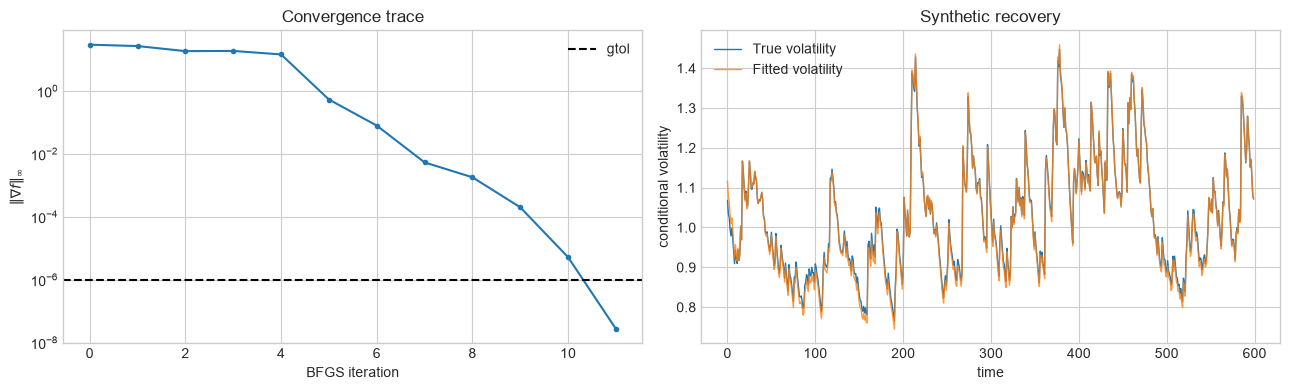

In [10]:
synthetic_custom = fit_custom(SYNTHETIC_RETURNS)
synthetic_reference = fit_reference(SYNTHETIC_RETURNS)

def comparison_table(fits, truth=None):
    rows = []
    for fit in fits:
        theta = fit["theta"]
        rows.append({
            "method": fit["method"], "mu": theta.mu, "omega": theta.omega,
            "alpha": theta.alpha, "beta": theta.beta,
            "persistence": theta.persistence, "nll": fit["fun"],
            "gradient_inf_norm": np.linalg.norm(fit["jac"], np.inf),
            "iterations": fit["nit"], "success": fit["success"]
        })
    if truth is not None:
        rows.append({"method": "True DGP", "mu": truth.mu, "omega": truth.omega,
                     "alpha": truth.alpha, "beta": truth.beta,
                     "persistence": truth.persistence})
    return pd.DataFrame(rows)

synthetic_comparison = comparison_table(
    [synthetic_custom, synthetic_reference], TRUE_THETA
)
display(synthetic_comparison)

fitted_variance = filter_variance(SYNTHETIC_RETURNS, synthetic_custom["theta"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
trace = synthetic_custom["history"]
axes[0].semilogy(trace["iteration"], trace["gradient_inf_norm"], marker="o", ms=3)
axes[0].axhline(1e-6, color="black", ls="--", label="gtol")
axes[0].set(xlabel="BFGS iteration", ylabel=r"$\|\nabla f\|_\infty$", title="Convergence trace")
axes[0].legend()
axes[1].plot(np.sqrt(TRUE_VARIANCE[:600]), label="True volatility", lw=1)
axes[1].plot(np.sqrt(fitted_variance[:600]), label="Fitted volatility", lw=1, alpha=.8)
axes[1].set(xlabel="time", ylabel="conditional volatility", title="Synthetic recovery")
axes[1].legend()
plt.tight_layout(); plt.show()

parameter_gap = np.max(np.abs(
    synthetic_custom["theta"].as_array()-synthetic_reference["theta"].as_array()
))
assert parameter_gap < 1e-5

## 7. Observed-information inference and residual diagnostics

At an interior MLE $\widehat u$, the observed information on the unconstrained scale is

$$\mathcal I(\widehat u)=\nabla_u^2 f(\widehat u).$$

We approximate it by central differences of the analytic gradient, symmetrize it, verify positive definiteness, and invert it. The delta method moves covariance to the natural scale:

$$
\widehat{\operatorname{Cov}}(\widehat\theta)
=J\,\mathcal I(\widehat u)^{-1}J^\top.
$$

Wald intervals are model-based. Standardized residuals
$z_t=(r_t-\widehat\mu)/\sqrt{\widehat h_t}$ are checked using Ljung–Box statistics for $z_t$ and $z_t^2$. These diagnostics assess serial dependence and remaining volatility clustering; they are **not** optimizer convergence tests.

In [11]:
def numerical_hessian_from_gradient(gradient, x, relative_step=1e-4):
    x = np.asarray(x, dtype=float)
    H = np.empty((len(x), len(x)))
    for j in range(len(x)):
        h = relative_step * max(1.0, abs(x[j]))
        forward, backward = x.copy(), x.copy()
        forward[j] += h
        backward[j] -= h
        H[:, j] = (gradient(forward)-gradient(backward))/(2*h)
    return 0.5*(H+H.T)


def observed_information(fit, returns, level=.95):
    H = numerical_hessian_from_gradient(
        lambda u: gaussian_nll_and_gradient(u, returns)[1], fit["x"]
    )
    eigenvalues = np.linalg.eigvalsh(H)
    if eigenvalues.min() <= 0:
        raise np.linalg.LinAlgError("Observed information is not positive definite.")
    covariance_u = np.linalg.inv(H)
    J = transform_jacobian(fit["x"])
    covariance_theta = J @ covariance_u @ J.T
    se = np.sqrt(np.maximum(np.diag(covariance_theta), 0.0))
    estimate = fit["theta"].as_array()
    critical = norm.ppf(0.5+level/2)
    table = pd.DataFrame({
        "parameter": ["mu", "omega", "alpha", "beta"],
        "estimate": estimate, "std_error": se,
        "lower_95": estimate-critical*se, "upper_95": estimate+critical*se
    })
    return table, eigenvalues


def autocorrelations(x, max_lag):
    centered = np.asarray(x)-np.mean(x)
    denominator = centered @ centered
    return np.array([(centered[k:]@centered[:-k])/denominator
                     for k in range(1, max_lag+1)])


def ljung_box(x, lags=20):
    x = np.asarray(x)
    rho = autocorrelations(x, lags)
    k = np.arange(1, lags+1)
    Q = len(x)*(len(x)+2)*np.sum(rho**2/(len(x)-k))
    return Q, chi2.sf(Q, lags)


def diagnostics_table(returns, theta, lags=20):
    h = filter_variance(returns, theta)
    z = (np.asarray(returns)-theta.mu)/np.sqrt(h)
    rows = []
    for label, series in [("z_t", z), ("z_t^2", z**2)]:
        Q, p = ljung_box(series, lags)
        rows.append({"series": label, "lags": lags, "Q": Q, "p_value": p})
    return pd.DataFrame(rows), z, h

synthetic_wald, synthetic_eigenvalues = observed_information(
    synthetic_custom, SYNTHETIC_RETURNS
)
synthetic_diagnostics, _, _ = diagnostics_table(
    SYNTHETIC_RETURNS, synthetic_custom["theta"]
)
display(synthetic_wald)
display(synthetic_diagnostics)
print("Observed-information eigenvalues:", synthetic_eigenvalues)

,parameter,estimate,std_error,lower_95,upper_95
0,mu,-0.000818,0.015993,-0.032163,0.030527
1,omega,0.044586,0.010097,0.024796,0.064377
2,alpha,0.082201,0.010938,0.060762,0.103639
3,beta,0.882007,0.016392,0.849879,0.914136


,series,lags,Q,p_value
0,z_t,20,12.592279,0.894185
1,z_t^2,20,7.280980,0.995657


Observed-information eigenvalues: [   6.664643   59.684873  626.88374  3912.254869]


## 8. Real-data case study: OTE daily equity returns

The local CSV contains a dated Greek-equity price history. We select OTE, sort by date, remove missing prices, and compute percentage log returns

$$r_t=100[\log(P_t)-\log(P_{t-1})].$$

The same objective and analytic gradient are used without changing the optimizer. Here the latent volatility and true parameters are unknown, so the reference-solver agreement, convergence traces, stationarity slack, Hessian eigenvalues, and residual diagnostics matter more than parameter-recovery error.

Observations: 2,134
Date range: 2018-01-03 to 2026-08-13
count    2134.000000
mean        0.044069
std         1.616994
min       -11.343570
25%        -0.837081
50%         0.000000
75%         0.923002
max        12.703628


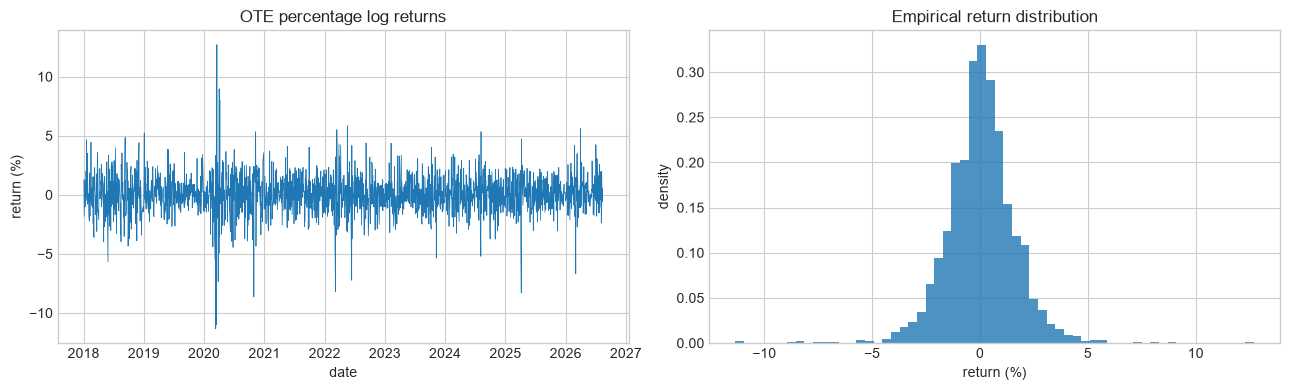

In [12]:
data_path = Path("greek_equity_prices.csv")
prices = pd.read_csv(data_path, parse_dates=["Date"])
prices = prices.sort_values("Date").dropna(subset=["OTE"])
real_returns = 100*np.log(prices["OTE"]).diff().dropna().to_numpy()
return_dates = prices["Date"].iloc[1:].to_numpy()

print(f"Observations: {len(real_returns):,}")
print(f"Date range: {pd.Timestamp(return_dates[0]).date()} to {pd.Timestamp(return_dates[-1]).date()}")
print(pd.Series(real_returns).describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(return_dates, real_returns, lw=.55)
axes[0].set(title="OTE percentage log returns", xlabel="date", ylabel="return (%)")
axes[1].hist(real_returns, bins=60, density=True, alpha=.8)
axes[1].set(title="Empirical return distribution", xlabel="return (%)", ylabel="density")
plt.tight_layout(); plt.show()

,method,mu,omega,alpha,beta,persistence,nll,gradient_inf_norm,iterations,success
0,Custom BFGS + Armijo,0.067259,0.183353,0.121675,0.805792,0.927467,3883.459448,1.033401e-07,11,True
1,SciPy BFGS reference,0.067259,0.183353,0.121675,0.805792,0.927467,3883.459448,1.300794e-08,11,True


,parameter,estimate,std_error,lower_95,upper_95
0,mu,0.067259,0.029801,0.008849,0.125669
1,omega,0.183353,0.050087,0.085184,0.281522
2,alpha,0.121675,0.019123,0.084194,0.159156
3,beta,0.805792,0.034071,0.739013,0.872571


,series,lags,Q,p_value
0,z_t,20,21.735527,0.355032
1,z_t^2,20,25.319176,0.189492


Observed-information eigenvalues: [   4.224272   40.56953   524.777423 1128.328593]
Stationarity slack: 0.072533


,model,parameters,nll,AIC,BIC
0,constant Gaussian variance,2,4053.048047,8110.096093,8121.42760
1,"GARCH(1,1)",4,3883.459448,7774.918896,7797.58191


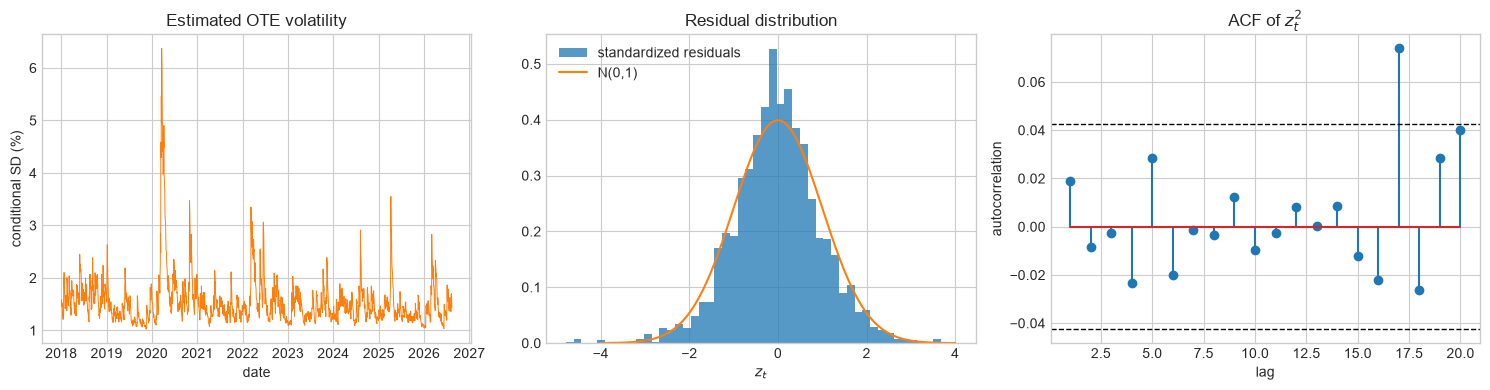

In [13]:
real_custom = fit_custom(real_returns)
real_reference = fit_reference(real_returns)
real_comparison = comparison_table([real_custom, real_reference])
display(real_comparison)

real_wald, real_eigenvalues = observed_information(real_custom, real_returns)
real_diagnostics, real_z, real_variance = diagnostics_table(
    real_returns, real_custom["theta"]
)
display(real_wald)
display(real_diagnostics)
print("Observed-information eigenvalues:", real_eigenvalues)
print(f"Stationarity slack: {1-real_custom['theta'].persistence:.6f}")

# Compare against a Gaussian constant-variance baseline through AIC/BIC.
baseline_variance = np.mean((real_returns-real_returns.mean())**2)
baseline_nll = .5*len(real_returns)*(np.log(2*np.pi)+np.log(baseline_variance)+1)
def aic_bic(nll, k, n):
    return 2*k+2*nll, np.log(n)*k+2*nll
model_comparison = pd.DataFrame([
    {"model": "constant Gaussian variance", "parameters": 2, "nll": baseline_nll,
     "AIC": aic_bic(baseline_nll, 2, len(real_returns))[0],
     "BIC": aic_bic(baseline_nll, 2, len(real_returns))[1]},
    {"model": "GARCH(1,1)", "parameters": 4, "nll": real_custom["fun"],
     "AIC": aic_bic(real_custom["fun"], 4, len(real_returns))[0],
     "BIC": aic_bic(real_custom["fun"], 4, len(real_returns))[1]}
])
display(model_comparison)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(return_dates, np.sqrt(real_variance), lw=.7, color="tab:orange")
axes[0].set(title="Estimated OTE volatility", xlabel="date", ylabel="conditional SD (%)")
axes[1].hist(real_z, bins=50, density=True, alpha=.75, label="standardized residuals")
grid = np.linspace(-4, 4, 300)
axes[1].plot(grid, np.exp(-grid**2/2)/np.sqrt(2*np.pi), label="N(0,1)")
axes[1].set(title="Residual distribution", xlabel=r"$z_t$")
axes[1].legend()
acf_sq = autocorrelations(real_z**2, 20)
axes[2].stem(np.arange(1, 21), acf_sq)
axes[2].axhline(1.96/np.sqrt(len(real_z)), color="black", ls="--", lw=1)
axes[2].axhline(-1.96/np.sqrt(len(real_z)), color="black", ls="--", lw=1)
axes[2].set(title=r"ACF of $z_t^2$", xlabel="lag", ylabel="autocorrelation")
plt.tight_layout(); plt.show()

assert np.max(np.abs(real_custom["theta"].as_array()-real_reference["theta"].as_array())) < 1e-4
assert real_custom["theta"].persistence < 1.0

## 9. Interpretation and convergence checklist

**What the numerical evidence establishes**

- The analytic score agrees with finite differences.
- The custom BFGS and SciPy reference solver reach the same objective and parameter vector to numerical tolerance.
- The transformed parameterization satisfies all constraints at every iteration.
- Positive observed-information eigenvalues support local curvature and model-based Wald inference at the reported solution.
- Synthetic recovery checks the full estimation pipeline against known parameters.
- The OTE case shows volatility clustering and evaluates whether GARCH improves AIC/BIC over constant variance.

**What it does not establish**

- Agreement of two local solvers is strong evidence, but not a proof of the global optimum.
- A convergence flag does not imply a statistically adequate model.
- Gaussian QMLE on real returns does not make the innovations Gaussian.
- Wald intervals can be unreliable near the boundary $\alpha+\beta=1$ or under misspecification.

**Reproducibility:** the synthetic seed is fixed; the real CSV is stored locally; all implementation code is in this notebook; and the final assertions audit the derivative, reference-solver agreement, and stationarity constraint.